# Fast clonal embeddings construction with `py-fastglmpca`

In this notebook, we will build a clonal embedding with `py-fastlmpca`: quick alternative for the classical Skip-Gram approach.

The main difference with the classical `clone2vec` is that in the case of Poisson EPCA we can significantly simplify the calculation of the clonal embedding with the Alternating Poisson Regression approach (*[Weine et al., 2024](https://academic.oup.com/bioinformatics/article/40/8/btae494/7729117)*), which we implemented in the [`py-fastglmpca`](https://github.com/serjisa/py-fastglmpca) package with GPU support.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sclitr as sl

sc.set_figure_params(dpi=80)
sc.settings.verbosity = 3
sns.set_style("ticks")

## Clonal embedding

In this tutorial, we will read the clonal AnnData generated with the classical `clone2vec` and take the matrix of clonal neighbors in gene expression space from there.

In [2]:
clones = sc.read_h5ad("Weinreb_clones.h5ad")

Instead of calling `sl.tl.clone2vec()` function, we can call a wrapper around `py-fastglmpca`: `sc.tl.clone2vec_Poi()`.

In [3]:
sl.tl.clone2vec_Poi(clones)

fitting clone2vec_Poi embeddings
    GLM-PCA epochs:  17%|█▋        | 83/500 [01:22<06:55,  1.00it/s, Log-Likelihood=-1462331.5000, Δ=9.97e-05, LR=5.00e-01]
    finished (0:01:23): added
     .obsm['clone2vec_Poi'] embedding matrix.
     .uns['clone2vec_Poi'] training details.


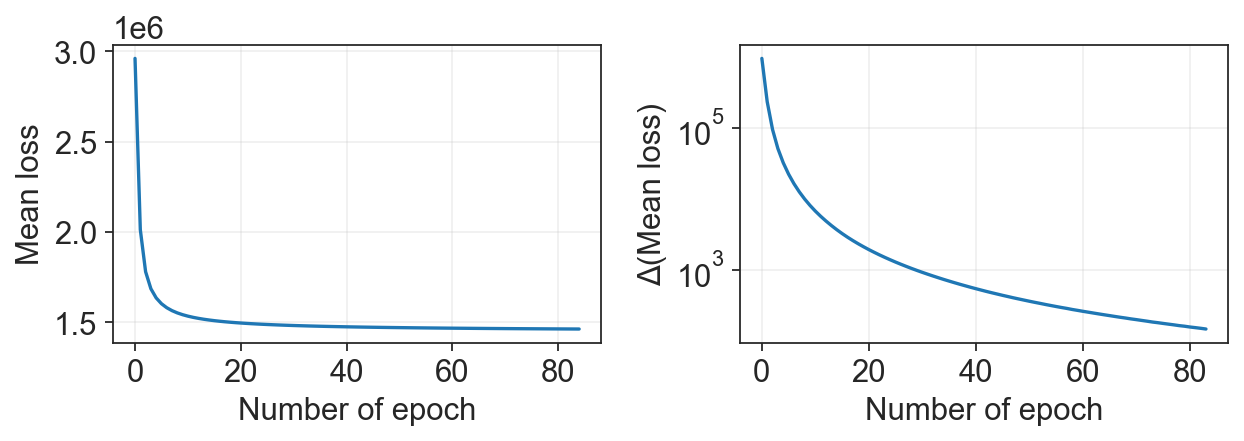

In [4]:
sl.pl.loss_history(clones, uns_key="clone2vec_Poi")

## Comparison of clonal embeddings

We can head-to-head inspect our clonal embeddings (at least visually). To do that, let's build a clustering and UMAP based on the new clonal embedding.

In [5]:
sc.pp.neighbors(clones, use_rep="clone2vec_Poi", n_neighbors=15, key_added="Poi")

computing neighbors
    finished: added to `.uns['Poi']`
    `.obsp['Poi_distances']`, distances for each pair of neighbors
    `.obsp['Poi_connectivities']`, weighted adjacency matrix (0:00:08)


In [6]:
sc.tl.umap(clones, neighbors_key="Poi", key_added="X_umap_Poi")

computing UMAP
    finished: added
    'X_umap_Poi', UMAP coordinates (adata.obsm)
    'X_umap_Poi', UMAP parameters (adata.uns) (0:00:11)


In [7]:
sc.tl.leiden(clones, neighbors_key="Poi", key_added="leiden_Poi",
             flavor="igraph", n_iterations=2)

running Leiden clustering
    finished: found 13 clusters and added
    'leiden_Poi', the cluster labels (adata.obs, categorical) (0:00:00)


To visually inspect differences between embeddings, let's plot a grid of both clusterings on both UMAPs.

<Axes: title={'center': 'clone2vec clusters'}, xlabel='X_umap1', ylabel='X_umap2'>

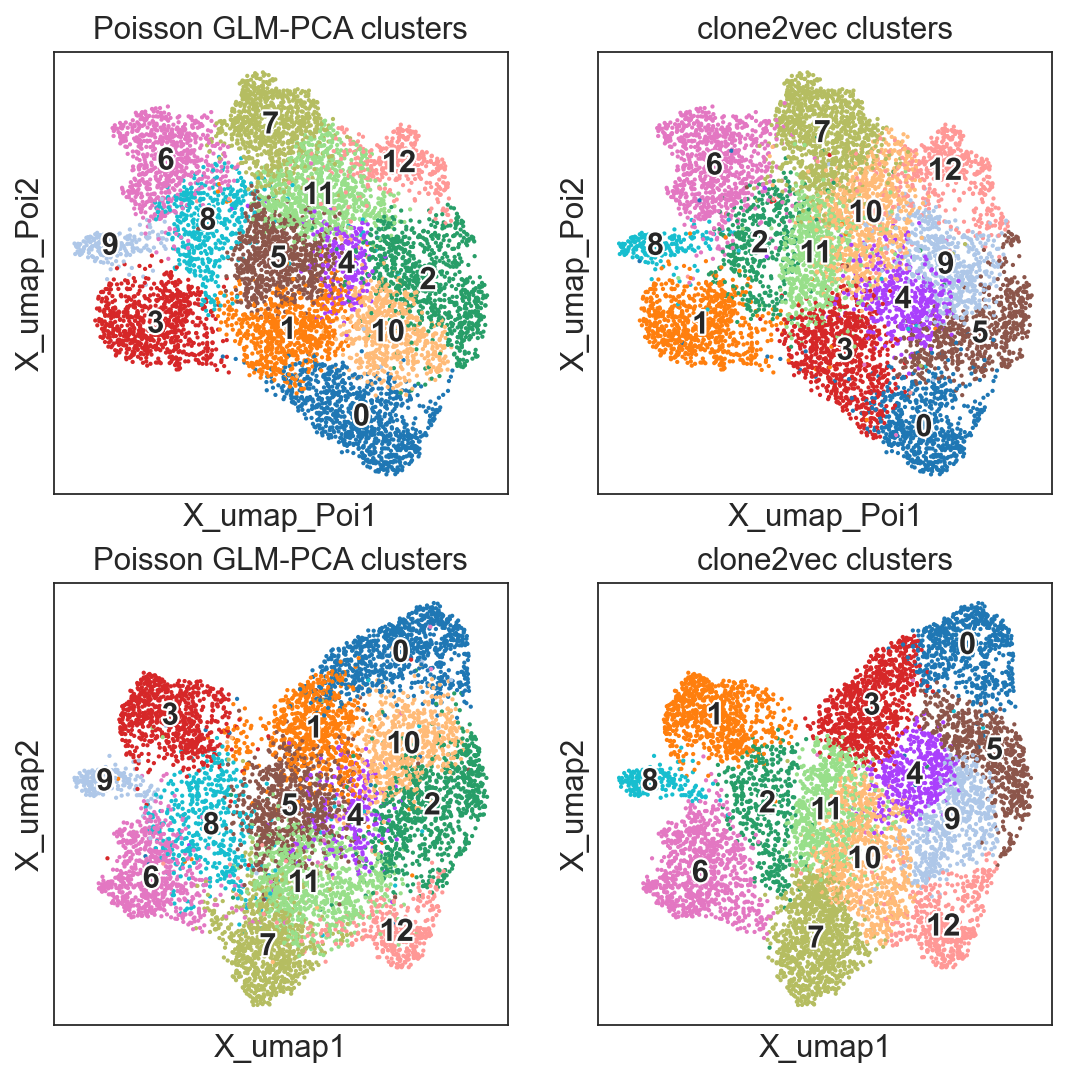

In [8]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(8, 8))

sc.pl.embedding(clones, basis="X_umap_Poi", ax=axes[0, 0], show=False, color="leiden_Poi", legend_loc="on data",
                legend_fontoutline=2, title="Poisson GLM-PCA clusters")
sc.pl.embedding(clones, basis="X_umap_Poi", ax=axes[0, 1], show=False, color="leiden", legend_loc="on data",
                legend_fontoutline=2, title="clone2vec clusters")

sc.pl.embedding(clones, basis="X_umap", ax=axes[1, 0], show=False, color="leiden_Poi", legend_loc="on data",
                legend_fontoutline=2, title="Poisson GLM-PCA clusters")
sc.pl.embedding(clones, basis="X_umap", ax=axes[1, 1], show=False, color="leiden", legend_loc="on data",
                legend_fontoutline=2, title="clone2vec clusters")

Now it looks a bit different (though clusters are pretty consistent between embeddings), but let's flip UMAP of the GLM-PCA embedding:

<Axes: title={'center': 'clone2vec clusters'}, xlabel='X_umap1', ylabel='X_umap2'>

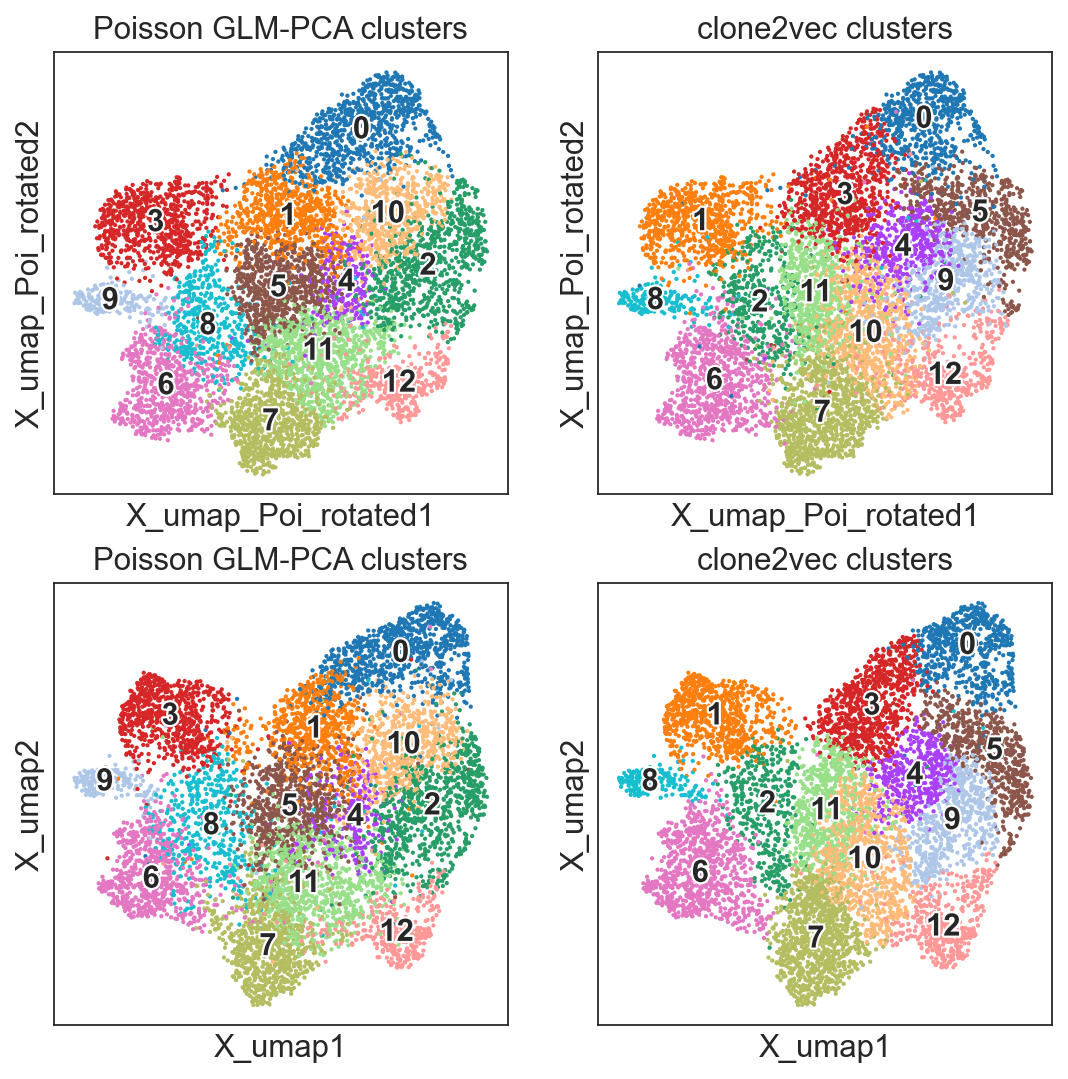

In [10]:
clones.obsm["X_umap_Poi_rotated"] = -clones.obsm["X_umap_Poi"].copy()
clones.obsm["X_umap_Poi_rotated"][:, 0] = -clones.obsm["X_umap_Poi_rotated"][:, 0]

fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(8, 8))

sc.pl.embedding(clones, basis="X_umap_Poi_rotated", ax=axes[0, 0], show=False, color="leiden_Poi", legend_loc="on data",
                legend_fontoutline=2, title="Poisson GLM-PCA clusters")
sc.pl.embedding(clones, basis="X_umap_Poi_rotated", ax=axes[0, 1], show=False, color="leiden", legend_loc="on data",
                legend_fontoutline=2, title="clone2vec clusters")

sc.pl.embedding(clones, basis="X_umap", ax=axes[1, 0], show=False, color="leiden_Poi", legend_loc="on data",
                legend_fontoutline=2, title="Poisson GLM-PCA clusters")
sc.pl.embedding(clones, basis="X_umap", ax=axes[1, 1], show=False, color="leiden", legend_loc="on data",
                legend_fontoutline=2, title="clone2vec clusters")

Now we see that even UMAPs look very similar.